# Fine-Tune Pretrained Commutative CNN Classifier

Load the pretrained commutative CNN encoder and fine-tune the full network on the current labeled action dataset.

In [2]:
%load_ext autoreload
%autoreload 2

from dataclasses import asdict
from pathlib import Path

import pandas as pd

from src.ml import (
    CommutativeCNNClassifier,
    CommutativeCNNConfig,
    LossWeightConfig,
    OptimizationConfig,
    display_experiment_summary,
    display_holdout_evaluation,
    fit_estimator_on_experiment,
    persist_experiment_artifacts,
    plot_training_history,
    prepare_multitask_experiment_data,
)
from src.dataset_config import load_current_dataset_artifact_path
from src.tensor_utils import build_tensor_embedding_2d, load_labeled_tensor_dataset, plot_tensor_embedding_2d

pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", None)
pd.set_option("display.width", None)
pd.set_option("display.expand_frame_repr", False)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [3]:
# User inputs

dataset_artifact_path = load_current_dataset_artifact_path()
pretrained_encoder_path = Path("artifacts/pretrained_commutative_cnn/encoder_state.pt")
experiment_output_dir = Path("artifacts/nb13C_commutative_cnn_full_finetune")
persist_artifacts = True

holdout_fraction = 0.25
validation_fraction_within_train = 0.20
train_num_random_rotations = 6
rotation_range_degrees = 12.0

model_config = CommutativeCNNConfig(
    spatial_conv_channels=(6, 8),
    spatial_kernel_size_z=(1, 1),
    spatial_kernel_size_xy=(5, 3),
    spatial_stride_z=(1, 1),
    spatial_stride_xy=(1, 1),
    spatial_pool_kernel_z=(1, 1),
    spatial_pool_kernel_xy=(2, 2),
    spatial_pool_stride_z=(1, 1),
    spatial_pool_stride_xy=(2, 2),
    temporal_st_channels=(12,),
    temporal_st_kernel_sizes=(3,),
    temporal_ts_channels=(8,),
    temporal_ts_kernel_sizes=(5,),
    spatial_agg_channels=(12,),
    spatial_agg_kernel_size_z=(3,),
    spatial_agg_kernel_size_xy=(3,),
    spatial_agg_stride_z=(1,),
    spatial_agg_stride_xy=(1,),
    spatial_agg_pool_kernel_z=(1,),
    spatial_agg_pool_kernel_xy=(2,),
    spatial_agg_pool_stride_z=(1,),
    spatial_agg_pool_stride_xy=(2,),
    patch_size_z=1,
    patch_size_xy=16,
    embedding_dim=8,
    num_prototypes=8,
    dropout=0.5,
)
optimization_config = OptimizationConfig(
    batch_size=8,
    epochs=100,
    learning_rate=5e-5,
    weight_decay=3e-3,
    early_stopping_patience=8,
    early_stopping_min_delta=0.0,
    scheduler_patience=2,
    scheduler_factor=0.7,
    scheduler_min_lr=1e-6,
    validation_split=0.0,
    random_state=0,
    standardize=True,
    device=None,
    verbose=True,
)
loss_weight_config = LossWeightConfig(
    action_weight=1.0,
    compound_weight=0.05,
    concentration_weight=0.05,
    consistency_weight=0.05,
    feature_weight=0.0,
    prototype_temperature=0.1,
)

In [4]:
dataset = load_labeled_tensor_dataset(dataset_artifact_path)
experiment = prepare_multitask_experiment_data(
    dataset,
    holdout_fraction=holdout_fraction,
    validation_fraction_within_train=validation_fraction_within_train,
    train_num_random_rotations=train_num_random_rotations,
    rotation_range_degrees=rotation_range_degrees,
    random_state=optimization_config.random_state,
)
display_experiment_summary(experiment)

,split,n_samples
0,train_augmented,1155
1,train_base,165
2,val,42
3,holdout,70


,mechanism_of_action,compound,concentration_band,n_samples
0,mAChR_Agonist_NonSelective,Pilocarpine,high,56
1,AChE_Inhibitor_Reversible,Phenserine,high,49
2,AChE_Inhibitor_Reversible,Donepezil,control,42
3,AChE_Inhibitor_Reversible,Galantamine,control,42
4,NMDAR_Activation,Cis-ACPD,high,42
5,GABAAR_Antagonist,Bemegride,control,42
6,GABAAR_Antagonist,Gabazine,control,42
7,NMDAR_Activation,N-methyl-D-aspartate,high,35
8,NMDAR_Activation,Cis-ACPD,control,35
9,GABAAR_Antagonist,Gabazine,mid,35


cols:
    ep=epoch
    lr=learning_rate
    eta=estimated_time_remaining
    trL=train_loss
    trA=train_action_loss
    trCC=train_commutative_consistency_loss
    trFA=train_feature_alignment_loss
    trCo=train_compound_loss
    trCn=train_concentration_loss
    vaL=val_loss
    vaA=val_action_loss
    vaCC=val_commutative_consistency_loss
    vaFA=val_feature_alignment_loss
    vaCo=val_compound_loss
    vaCn=val_concentration_loss
     ep       lr       eta |      trL      trA     trCC     trFA     trCo     trCn |      vaL      vaA     vaCC     vaFA     vaCo     vaCn
001/100 5.00e-05   2:08:56 |   1.9792   1.6914   2.1156   0.0606   2.5395   1.1015 |   1.9475   1.6663   2.0119   0.0180   2.5146   1.0969
002/100 5.00e-05   2:08:29 |   1.9568   1.6689   2.1176   0.0683   2.5384   1.1028 |   1.9316   1.6504   2.0129   0.0273   2.5139   1.0972
003/100 5.00e-05   2:07:44 |   1.9399   1.6521   2.1238   0.0844   2.5312   1.1014 |   1.9156   1.6354   1.9962   0.0321   2.5093   1.0979
004

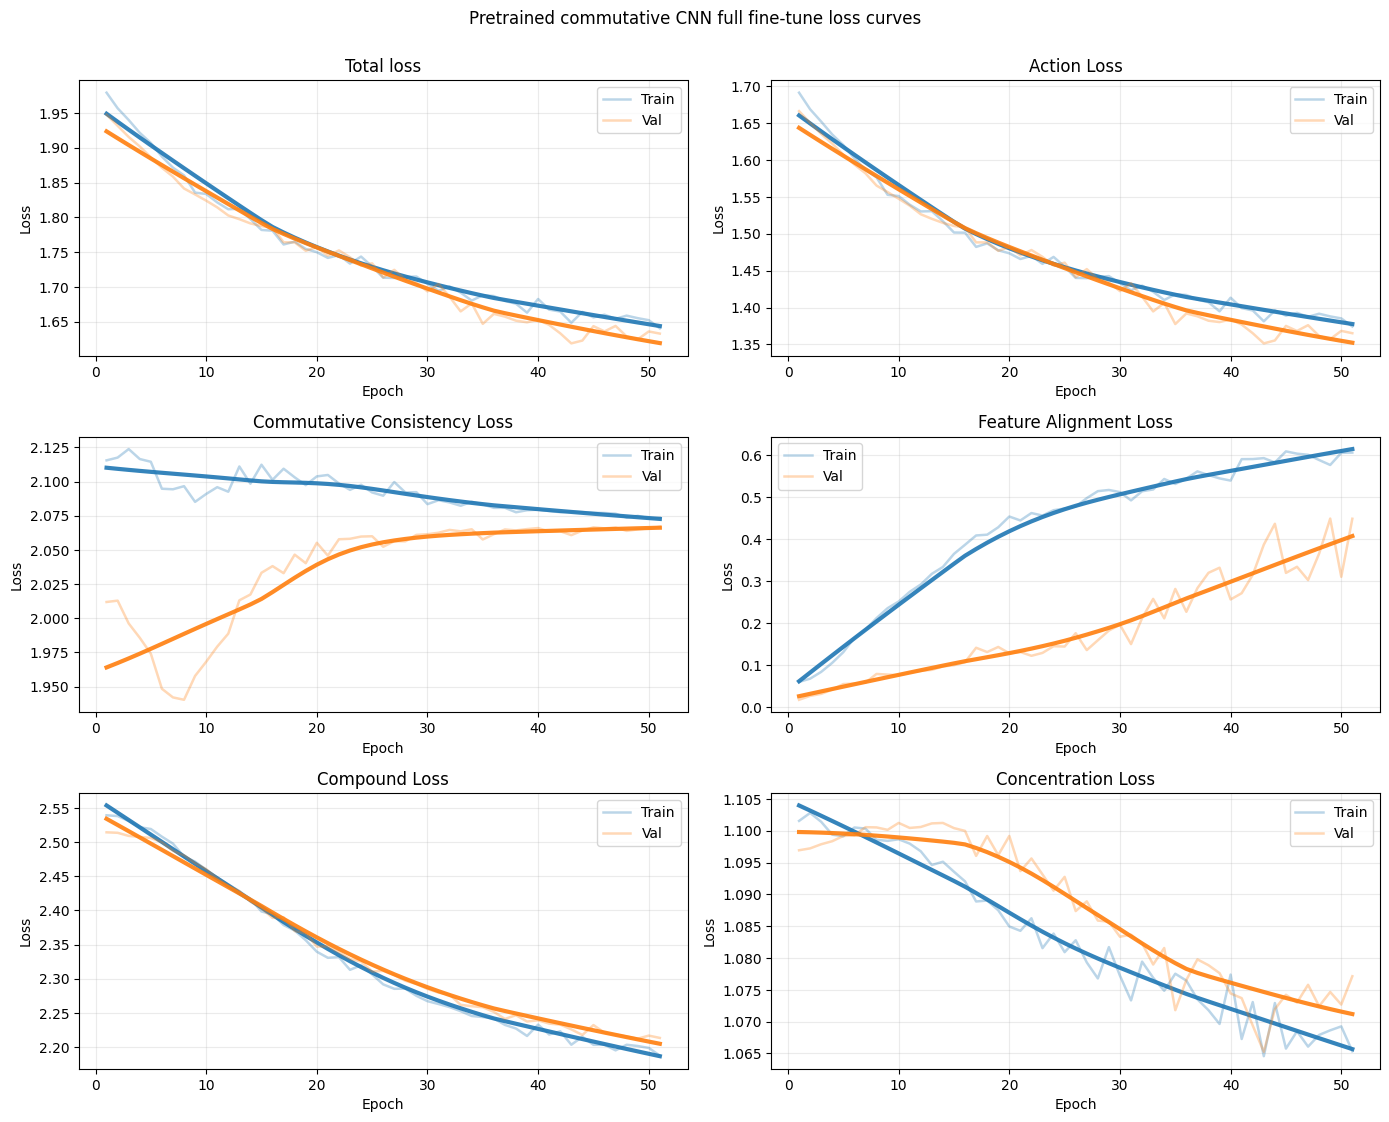

In [5]:
model = CommutativeCNNClassifier(
    model_config=model_config,
    optimization_config=optimization_config,
    loss_weight_config=loss_weight_config,
    pretrained_state_path=pretrained_encoder_path,
    freeze_backbone=False,
)
fit_estimator_on_experiment(model, experiment)
plot_training_history(model, title="Pretrained commutative CNN full fine-tune loss curves", loess_frac=0.6);


## Holdout report: action


,precision,recall,f1-score,support
class,,,,
Water,0.407407,0.916667,0.564103,24.0
GABAAR_Antagonist,0.750000,0.250000,0.375000,12.0
NMDAR_Activation,0.666667,0.800000,0.727273,10.0
AChE_Inhibitor_Reversible,0.000000,0.000000,0.000000,12.0
mAChR_Agonist_NonSelective,0.000000,0.000000,0.000000,12.0


,value
accuracy,0.471429
macro_precision,0.364815
macro_recall,0.393333
macro_f1,0.333275
weighted_precision,0.363492
weighted_recall,0.471429
weighted_f1,0.361588
n_samples,70.000000
roc_auc_ovr_macro,0.754309
average_precision_macro,0.483583


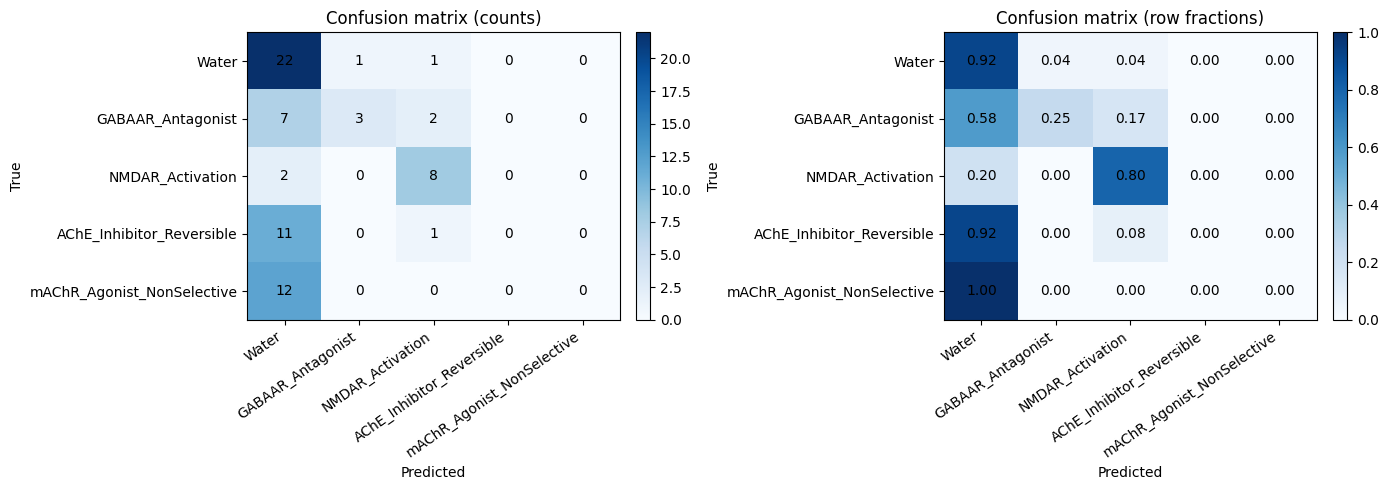


## Holdout report: compound


,precision,recall,f1-score,support
class,,,,
Control,0.353846,0.958333,0.516854,24.0
Bemegride,0.000000,0.000000,0.000000,5.0
Bicuculline,0.000000,0.000000,0.000000,3.0
Gabazine,0.000000,0.000000,0.000000,4.0
(RS)-(Tetrazol-5-yl)glycine,0.000000,0.000000,0.000000,3.0
Cis-ACPD,0.000000,0.000000,0.000000,3.0
N-methyl-D-aspartate,0.600000,0.750000,0.666667,4.0
Donepezil,0.000000,0.000000,0.000000,6.0
Galantamine,0.000000,0.000000,0.000000,5.0


,value
accuracy,0.371429
macro_precision,0.073373
macro_recall,0.131410
macro_f1,0.091040
weighted_precision,0.155604
weighted_recall,0.371429
weighted_f1,0.215302
n_samples,70.000000
roc_auc_ovr_macro,0.680329
average_precision_macro,0.248742


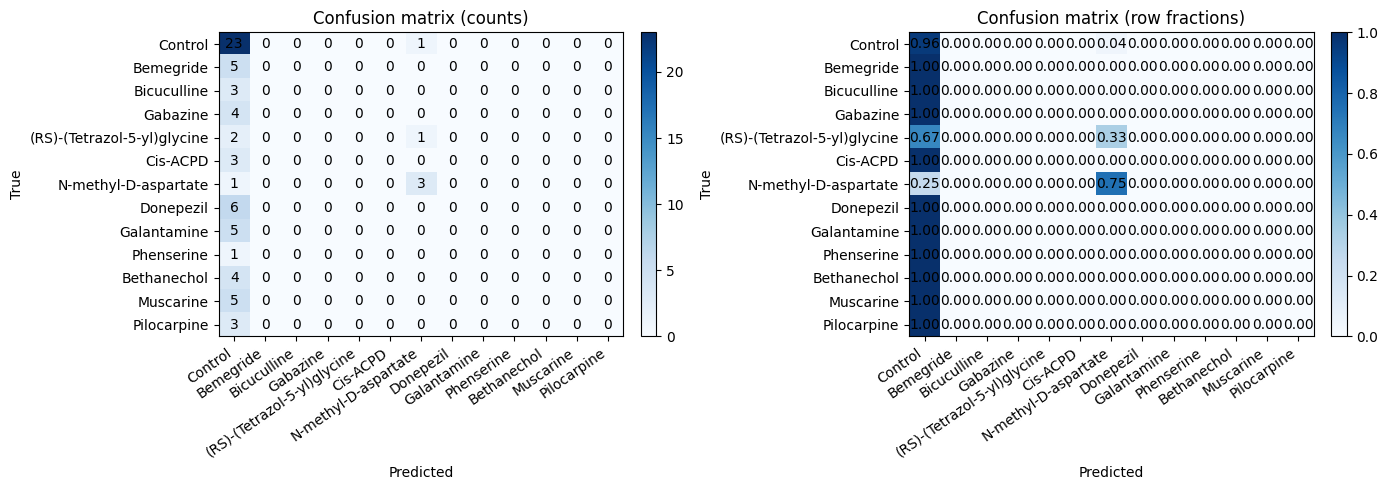


## Holdout report: concentration


,precision,recall,f1-score,support
class,,,,
control,0.400000,0.916667,0.556962,24.0
high,0.615385,0.347826,0.444444,23.0
mid,0.500000,0.043478,0.080000,23.0


,value
accuracy,0.442857
macro_precision,0.505128
macro_recall,0.435990
macro_f1,0.360469
weighted_precision,0.503626
weighted_recall,0.442857
weighted_f1,0.363276
n_samples,70.000000
roc_auc_ovr_macro,0.636872
average_precision_macro,0.485357


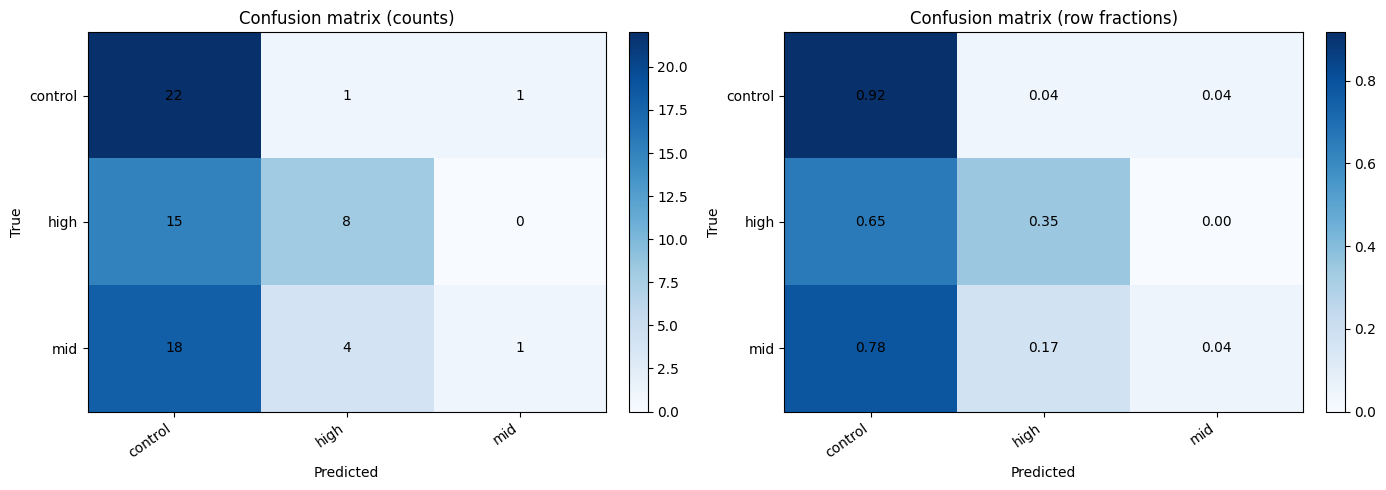

In [6]:
holdout_evaluation = display_holdout_evaluation(model, experiment)

(<Figure size 1550x1050 with 1 Axes>,
 <Axes: title={'center': 'Holdout embedding projection by action'}, xlabel='Component 1', ylabel='Component 2'>)

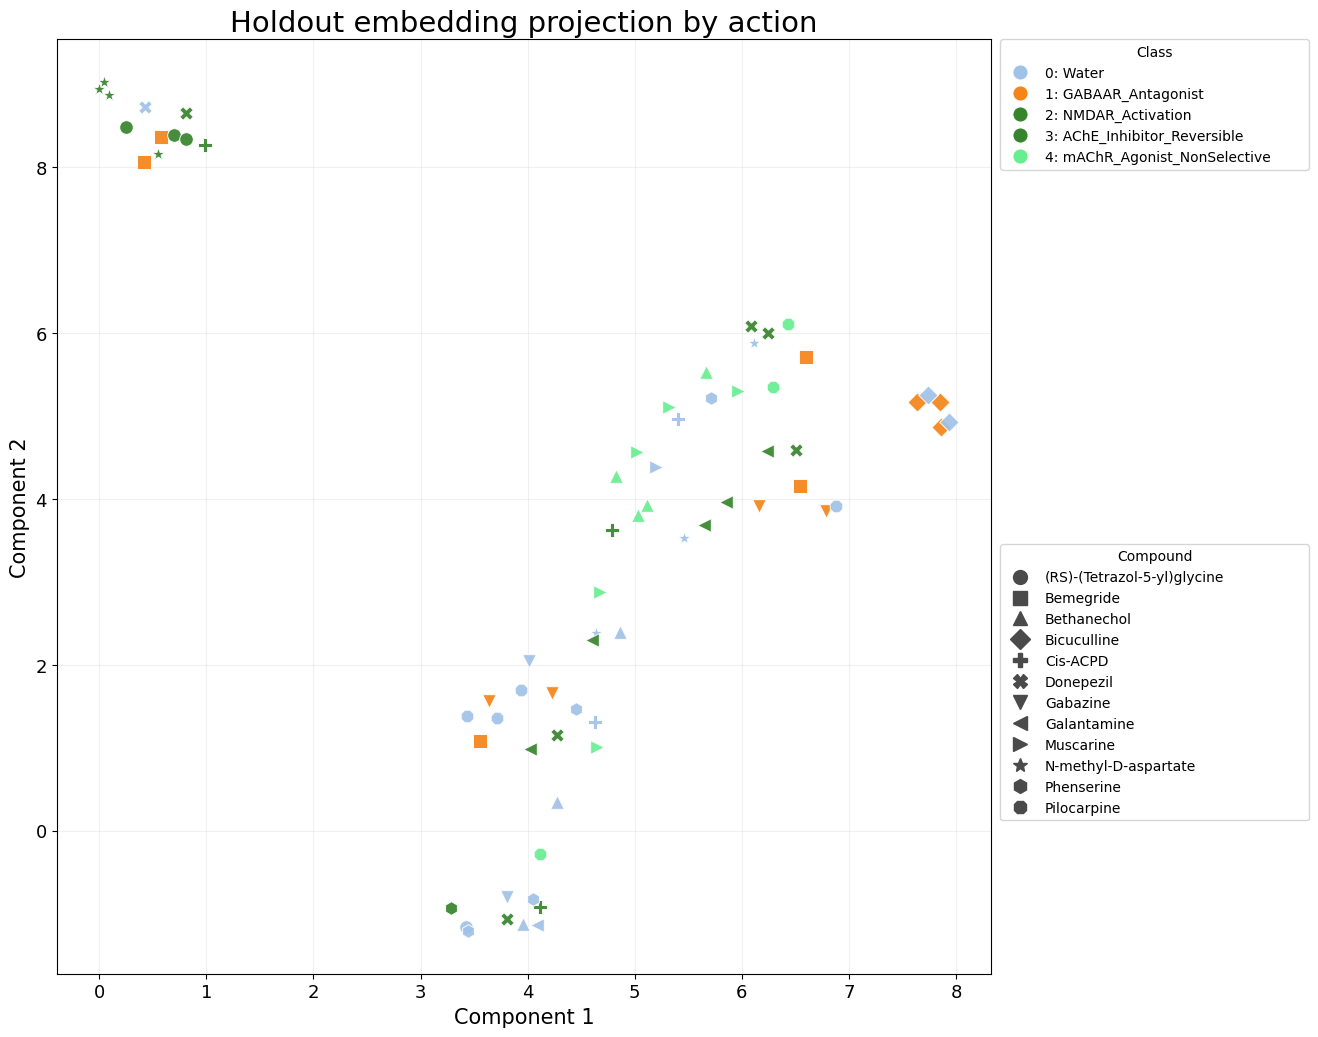

In [7]:
holdout_embedding_projection = build_tensor_embedding_2d(
    model.transform(experiment.splits.X_holdout),
    experiment.y_true_holdout["action"],
    label_map=experiment.label_maps["action"],
    metadata=experiment.splits.metadata_holdout,
    method="umap",
    random_state=optimization_config.random_state,
)
plot_tensor_embedding_2d(
    holdout_embedding_projection,
    title="Holdout embedding projection by action",
    marker_column="compound",
)

In [8]:
run_config = {
    "dataset_artifact_path": dataset_artifact_path,
    "pretrained_encoder_path": pretrained_encoder_path,
    "freeze_backbone": False,
    "holdout_fraction": holdout_fraction,
    "validation_fraction_within_train": validation_fraction_within_train,
    "train_num_random_rotations": train_num_random_rotations,
    "rotation_range_degrees": rotation_range_degrees,
    "model_config": asdict(model_config),
    "optimization_config": asdict(optimization_config),
    "loss_weight_config": asdict(loss_weight_config),
}
if persist_artifacts:
    experiment_artifacts = persist_experiment_artifacts(
        output_dir=experiment_output_dir,
        estimator=model,
        reports=holdout_evaluation.reports,
        config=run_config,
    )
    experiment_artifacts